# Figure 3: entanglement entropy scaling between random benchmarking and kicked Ising circuits

In [1]:
from IPython.display import clear_output

import fccb

import sys
sys.path.append('../')

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix, partial_trace, entropy
from qiskit.transpiler import CouplingMap

from matplotlib import pyplot as plt
import numpy as np
import ast

coupling_map = CouplingMap(np.load('../brisbane_coupling_map.npy')) # Coupling map of ibm_brisbane device
Ls = np.load('../layers.npy') # Three layers of two-qubit gates as per IBM experiment

Function to, given a device coupling map and a fixed number of qubits $N$, generate a set of benchmarking circuit parameters (pick a connected subset of $N$ device qubits and a random weight-two Pauli string $O$ to measure on those qubits) and generate the corresponding benchmarking circuit $U_O$. The circuit data returns as a list of gates where each gate is something like `['XY', [q0, q1]]`, in this case indicating the gate $e^{iX_{q_0}Y_{q_1}\theta/2}$.

In [2]:
def generate_experiment(coupling_map, N, n_random_layers=None):

    # Iteratively pick a set of N connected device qubits
    central_qubit = np.random.choice([i for i in range(127)])
    device_qubits = list([central_qubit])
    for i in range(N-1):
        connected_qubits_list = []
        for q in device_qubits:
            connected_qubits_list = connected_qubits_list + fccb.connected_qubits(q, coupling_map)
        connected_qubits_list = [q for q in connected_qubits_list if q not in device_qubits]
        new_qubit = np.random.choice(connected_qubits_list)
        device_qubits.append(new_qubit)

    device_qubits.sort()

    # Pick random weight-two Pauli acting on N qubits
    pauli_to_measure = fccb.generate_random_pauli(N,weight=2)
    
    # Generate benchmarking circuit data (1 layer brute force, n_random_layers layers random)
    if n_random_layers is not None:
        gates_bf, _ = fccb.circuit_brute_force_with_structure(pauli_to_measure, device_qubits, n_layers=1, show_progress=True)
        gates_rd = fccb.circuit_random_evolve_with_structure(N, device_qubits, n_layers=n_random_layers, show_progress=False)
        circuit_gates = gates_rd + gates_bf
        return device_qubits, pauli_to_measure, circuit_gates
    
    else:
        return device_qubits, pauli_to_measure

Function to generate a standard kicked Ising circuit as per the IBM paper ($\theta_h$ unfixed), given a connected subset of qubits
as a list of integers and a number of Trotter layers.

In [3]:
def IBM_experiment_circ(device_qubits, n_layers):
    
    N = len(device_qubits)
    qc = QuantumCircuit(N)
    theta = Parameter('theta')
    
    for layer in range(n_layers):
        
        # Rx on each qubit
        for i in range(N):
            qc.rx(theta, i)
            
        # Rzz over 3 layers
        for Li in Ls:
            for q0, q1 in Li:
                if q0 in device_qubits and q1 in device_qubits:
                    i0, i1 = device_qubits.index(q0), device_qubits.index(q1)
                    qc.rzz(-np.pi/2, i0, i1)

    return qc, theta

For each number of qubits $N \in \{3,4,\dots,10\}$, we generate 1000 sets of random parameters (set of device qubits, weight-two Pauli $P$ to measure). For each set of parameters, we generate the benchmarking circuit and measure its entanglement entropy across the subspace spanned by the two qubits on which $P$ acts non-trivially. We then repeat this process for the kicked Ising circuit with $\theta_h = \pi/4$. Data is saved in a text file.

In [4]:
filename = 'figure_3_entropies.txt'

In [5]:
# for n_qubits in [3,4,5,6,7,8,9,10]:
        
#     for i in range(1000):
    
#         # Generate random experimental parameters and corresponding benchmarking circuit
#         device_qubits, pauli_to_measure, circuit_gates = generate_experiment(coupling_map, n_qubits, n_random_layers=9)
#         measured_qs = [k for k in range(len(device_qubits)) if pauli_to_measure[k] != 'I']
        
#         # Save device_qubits and Pauli P to text file
#         with open(filename, 'a') as file:
#             file.write(str(device_qubits) + '\n' + str(pauli_to_measure) + '\n')
        
#         # Entropy analysis of my circs
#         clear_output(wait=True)
#         print(str(n_qubits) + ' qubits')
#         print(str(i+1) + ' of 1000 (my circs)')
#         qc, theta = fccb.pauli_list_to_circuit(circuit_gates, device_qubits)
#         qc_t = qc.assign_parameters({theta:np.pi/8}) # pi/8 since we don't divide by 2 in exponent
#         dm = DensityMatrix(qc_t)
#         dm_pt = partial_trace(dm, measured_qs)
#         ent = entropy(dm_pt, base=np.e) 
#         with open(filename, 'a') as file:
#             file.write(str(ent) + '\n') 
        
        
#         # Entropy analysis of IBM circs
#         clear_output(wait=True)
#         print(str(n_qubits) + ' qubits')
#         print(str(i+1) + ' of 1000 (IBM circs)')
#         qc, theta = IBM_experiment_circ(device_qubits, n_layers=20)
#         qc_t = qc.assign_parameters({theta:np.pi/4})
#         dm = DensityMatrix(qc_t)
#         dm_pt = partial_trace(dm, measured_qs)
#         ent = entropy(dm_pt, base=np.e)
#         clear_output(wait=True)
#         with open(filename, 'a') as file:
#             file.write(str(ent) + '\n' + '-----------------------------------------------' + '\n')

Finally, we perform the data analysis. For each number of qubits we calculate the means and standard deviations of the entropies for the benchmarking and kicked Ising circuits. 

In [6]:
# Import entropy data from file, grouped by number of qubits

def read_lines(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 5):
            if i + 4 < len(lines):
                first_line = lines[i].strip()
                third_line = lines[i + 2].strip()
                fourth_line = lines[i + 3].strip()
                yield first_line, third_line, fourth_line

filename = 'figure_3_entropies.txt'

entropies_mine = [[],[],[],[],[],[],[],[]]
entropies_IBM = [[],[],[],[],[],[],[],[]] 

for first, third, fourth in read_lines('figure_3_entropies.txt'):
    
    N = len(ast.literal_eval(first))
    ent_mine = float(third)
    entropies_mine[N-3].append(ent_mine)
    ent_IBM = float(fourth)
    entropies_IBM[N-3].append(ent_IBM)
    

# Calculate means and standard deviations for error bars, 
# ensuring mean + std <= log(4), the theoretical limit

entropies_mean_mine = []
entropies_std_below_mine = []
entropies_std_above_mine = []
entropies_mean_IBM = []
entropies_std_below_IBM = []
entropies_std_above_IBM = []

for i in range(8):
    mean = np.mean(entropies_mine[i])
    std = np.std(entropies_mine[i])
    
    if mean - std < 0:
        err_below = mean
    else:
        err_below = std
        
    if mean + std > np.log(4):
        err_above = np.log(4) - mean
    else:
        err_above = std
        
    entropies_std_below_mine.append(err_below)
    entropies_std_above_mine.append(err_above)
    entropies_mean_mine.append(mean)
    
    mean = np.mean(entropies_IBM[i])
    std = np.std(entropies_IBM[i])
    
    if mean - std < 0:
        err_below = mean
    else:
        err_below = std
        
    if mean + std > np.log(4):
        err_above = np.log(4) - mean
    else:
        err_above = std
        
    entropies_std_below_IBM.append(err_below)
    entropies_std_above_IBM.append(err_above)
    entropies_mean_IBM.append(mean)

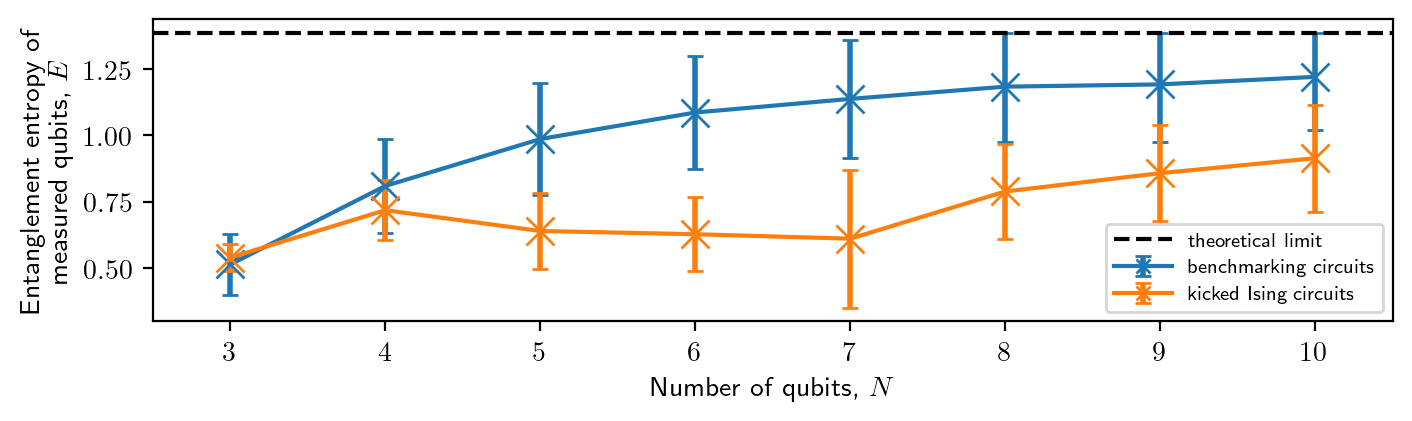

In [7]:
# Plot results

X = [3,4,5,6,7,8,9,10]
plt.rcParams['text.usetex'] = True
plt.figure(figsize=(8,2), dpi=200)

plt.errorbar(X, entropies_mean_mine, yerr=[entropies_std_below_mine, entropies_std_above_mine],
             fmt='-', marker='x', capsize=3, capthick=1, elinewidth=2, markersize=10)
plt.errorbar(X, entropies_mean_IBM, yerr=[entropies_std_below_IBM, entropies_std_above_IBM],
             fmt='-', marker='x', capsize=3, capthick=1, elinewidth=2, markersize=10)

plt.plot([2.5, 10.5],[np.log(4), np.log(4)], '--', color='black')

legend = plt.legend(labels=['theoretical limit','benchmarking circuits', 'kicked Ising circuits'], 
           prop={'size': 7}, markerscale=0.5, handlelength=3, loc='lower right')
plt.xlim([2.5, 10.5])
plt.xlabel('Number of qubits, $N$')
plt.ylabel('Entanglement entropy of \n measured qubits, $E$')

plt.savefig('entropies.pdf', bbox_inches='tight')
plt.show()